Data read and show

In [0]:
# CSV
movies_df = spark.read.csv("/Volumes/dbacademy/ingesting_data/myfiles/movies.csv", header=True, inferSchema=True)
ratings_df = spark.read.csv("/Volumes/dbacademy/ingesting_data/myfiles/ratings.csv", header=True, inferSchema=True)
tags_df = spark.read.csv("/Volumes/dbacademy/ingesting_data/myfiles/tags.csv", header=True, inferSchema=True)

# data check
movies_df.show(5)
ratings_df.show(5)
tags_df.show(5)

+-------+--------------------+--------------------+
|movieId|               title|              genres|
+-------+--------------------+--------------------+
|      1|    Toy Story (1995)|Adventure|Animati...|
|      2|      Jumanji (1995)|Adventure|Childre...|
|      3|Grumpier Old Men ...|      Comedy|Romance|
|      4|Waiting to Exhale...|Comedy|Drama|Romance|
|      5|Father of the Bri...|              Comedy|
+-------+--------------------+--------------------+
only showing top 5 rows
+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|     1|     17|   4.0|944249077|
|     1|     25|   1.0|944250228|
|     1|     29|   2.0|943230976|
|     1|     30|   5.0|944249077|
|     1|     32|   5.0|943228858|
+------+-------+------+---------+
only showing top 5 rows
+------+-------+-----------+----------+
|userId|movieId|        tag| timestamp|
+------+-------+-----------+----------+
|    22|  26479|Kevin Kline|1583038886|
|    22|  79592|  

data describe

In [0]:
# 컬럼 확인
movies_df.printSchema()
ratings_df.printSchema()

# 기본 통계
ratings_df.describe().show()

root
 |-- movieId: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- genres: string (nullable = true)

root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: double (nullable = true)
 |-- timestamp: integer (nullable = true)

+-------+------------------+------------------+------------------+--------------------+
|summary|            userId|           movieId|            rating|           timestamp|
+-------+------------------+------------------+------------------+--------------------+
|  count|          32000204|          32000204|          32000204|            32000204|
|   mean|100278.50641102163|29318.610121829224|3.5403956487277393|1.2752411995732634E9|
| stddev| 57949.04623325274| 50958.16087967063|1.0589862139453097| 2.561629759505963E8|
|    min|                 1|                 1|               0.5|           789652004|
|    max|            200948|            292757|               5.0|          1697164147|
+-------+-

In [0]:
from pyspark.sql.functions import col, avg

avg_ratings = ratings_df.groupBy("movieId").agg(avg("rating").alias("avg_rating"))
avg_ratings.show(7)

+-------+------------------+
|movieId|        avg_rating|
+-------+------------------+
|   2394| 3.463985668396343|
| 108932|3.6670575588781396|
|   3342|3.7815896739130435|
| 105211|3.4698085419734905|
|  41411|2.9693877551020407|
|  83086| 3.307142857142857|
| 114246|3.1896774193548385|
+-------+------------------+
only showing top 7 rows


In [0]:
from pyspark.sql.functions import split, explode

movies_with_genre = movies_df.withColumn(
    "genre",
    explode(split(movies_df["genres"], "\\|"))
)

movies_with_genre.show(5)

+-------+----------------+--------------------+---------+
|movieId|           title|              genres|    genre|
+-------+----------------+--------------------+---------+
|      1|Toy Story (1995)|Adventure|Animati...|Adventure|
|      1|Toy Story (1995)|Adventure|Animati...|Animation|
|      1|Toy Story (1995)|Adventure|Animati...| Children|
|      1|Toy Story (1995)|Adventure|Animati...|   Comedy|
|      1|Toy Story (1995)|Adventure|Animati...|  Fantasy|
+-------+----------------+--------------------+---------+
only showing top 5 rows


In [0]:
from pyspark.sql.functions import avg

genre_ratings = ratings_df.join(movies_with_genre, on="movieId")

genre_avg = genre_ratings.groupBy("genre").agg(
    avg("rating").alias("avg_rating")
).orderBy("avg_rating", ascending=False)

genre_avg.show()

+------------------+------------------+
|             genre|        avg_rating|
+------------------+------------------+
|         Film-Noir| 3.915774014636868|
|               War|3.7916994435766664|
|             Crime|3.6917711184948736|
|       Documentary|3.6911815290871948|
|             Drama|3.6824540581800784|
|           Mystery| 3.673102967818112|
|         Animation|3.6153322869262636|
|           Western|3.6001753109842554|
|              IMAX| 3.593312447839248|
|           Musical| 3.554276956937205|
|           Romance|3.5450028644529983|
|          Thriller|3.5317020152396505|
|         Adventure|3.5234385724723545|
|           Fantasy| 3.512174705402107|
|            Sci-Fi|3.4916991949223912|
|            Action| 3.476407141777424|
|          Children|3.4392409733948646|
|            Comedy|3.4323858239436777|
|(no genres listed)|3.3681574110778767|
|            Horror|3.3071549944529486|
+------------------+------------------+
only showing top 20 rows


In [0]:
from pyspark.sql.functions import count

genre_popularity = genre_ratings.groupBy("genre").agg(
    count("rating").alias("num_ratings")
).orderBy("num_ratings", ascending=False)

genre_popularity.show()

+------------------+-----------+
|             genre|num_ratings|
+------------------+-----------+
|             Drama|   13973271|
|            Comedy|   11206925|
|            Action|    9665213|
|          Thriller|    8679464|
|         Adventure|    7590522|
|            Sci-Fi|    5717337|
|           Romance|    5524615|
|             Crime|    5373051|
|           Fantasy|    3702759|
|          Children|    2731841|
|           Mystery|    2615322|
|            Horror|    2492315|
|         Animation|    2214562|
|               War|    1594110|
|              IMAX|    1494179|
|           Musical|    1159516|
|           Western|     596654|
|       Documentary|     427353|
|         Film-Noir|     304710|
|(no genres listed)|      55498|
+------------------+-----------+
only showing top 20 rows


In [0]:
avg_ratings_with_title = avg_ratings.join(movies_df, on="movieId", how="inner")
avg_ratings_with_title.select("title", "avg_rating").orderBy(col("avg_rating").desc()).show(10)

+--------------------+----------+
|               title|avg_rating|
+--------------------+----------+
|      Domingo (2007)|       5.0|
|De Superjhemp Ret...|       5.0|
|      Barnone (1997)|       5.0|
|      Churuli (2021)|       5.0|
|   Hysterical (2021)|       5.0|
|The Village Had N...|       5.0|
|The Wrong Girl (1...|       5.0|
|The Law and the F...|       5.0|
|The Beach Boys: M...|       5.0|
| Silvery Moon (1933)|       5.0|
+--------------------+----------+
only showing top 10 rows


In [0]:
from pyspark.sql.functions import count

count_ratings = ratings_df.groupBy("movieId").agg(count("rating").alias("num_ratings"))
top_movies = count_ratings.join(movies_df, on="movieId").orderBy(col("num_ratings").desc())
top_movies.select("title", "num_ratings").show(10)

+--------------------+-----------+
|               title|num_ratings|
+--------------------+-----------+
|Shawshank Redempt...|     102929|
| Forrest Gump (1994)|     100296|
| Pulp Fiction (1994)|      98409|
|  Matrix, The (1999)|      93808|
|Silence of the La...|      90330|
|Star Wars: Episod...|      85010|
|   Fight Club (1999)|      77332|
|Jurassic Park (1993)|      75233|
|Schindler's List ...|      73849|
|Lord of the Rings...|      73122|
+--------------------+-----------+
only showing top 10 rows


In [0]:
from pyspark.sql.functions import lower

tag_counts = tags_df.withColumn(
    "tag", lower(tags_df["tag"])
).groupBy("tag").count().orderBy("count", ascending=False)

tag_counts.show(10)


+------------------+-----+
|               tag|count|
+------------------+-----+
|            sci-fi|11437|
|       atmospheric|10088|
|            action| 9337|
|            comedy| 8784|
|             funny| 8088|
|           surreal| 7480|
|visually appealing| 7253|
|   based on a book| 6728|
|      twist ending| 6600|
|       dark comedy| 6153|
+------------------+-----+
only showing top 10 rows


In [0]:
tag_rating = tags_df.join(ratings_df, on=["userId", "movieId"])

tag_avg = tag_rating.groupBy("tag").agg(
    avg("rating").alias("avg_rating"),
    count("rating").alias("num_ratings")
).orderBy("num_ratings", ascending=False)

tag_avg.show(10)

+------------------+------------------+-----------+
|               tag|        avg_rating|num_ratings|
+------------------+------------------+-----------+
|            sci-fi| 3.961933764750666|      10508|
|       atmospheric| 4.213925544469477|       9321|
|            action|3.8667822211217038|       8077|
|            comedy|3.9288733324527803|       7571|
|             funny| 4.056887052341597|       7260|
|           surreal| 4.209635790077431|       6974|
|visually appealing| 4.159881622636062|       6927|
|      twist ending|4.2420066152149944|       6349|
| thought-provoking| 4.377865206979131|       5846|
|       dark comedy| 4.190825525897119|       5657|
+------------------+------------------+-----------+
only showing top 10 rows


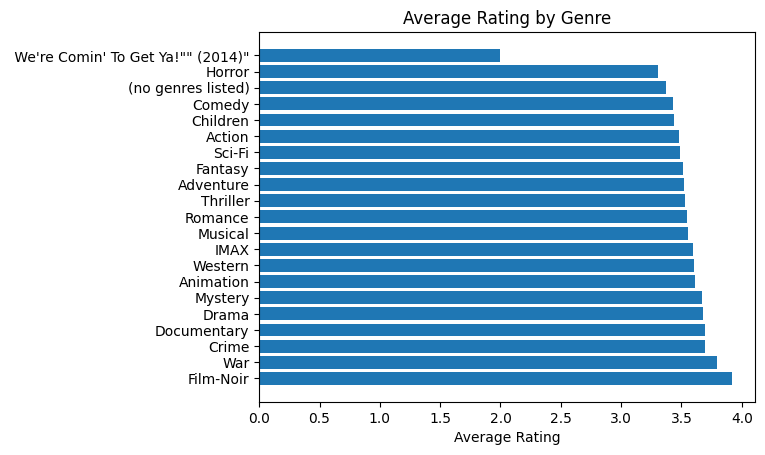

In [0]:
import matplotlib.pyplot as plt

genre_pd = genre_avg.toPandas()

plt.figure()
plt.barh(genre_pd["genre"], genre_pd["avg_rating"])
plt.xlabel("Average Rating")
plt.title("Average Rating by Genre")
plt.show()

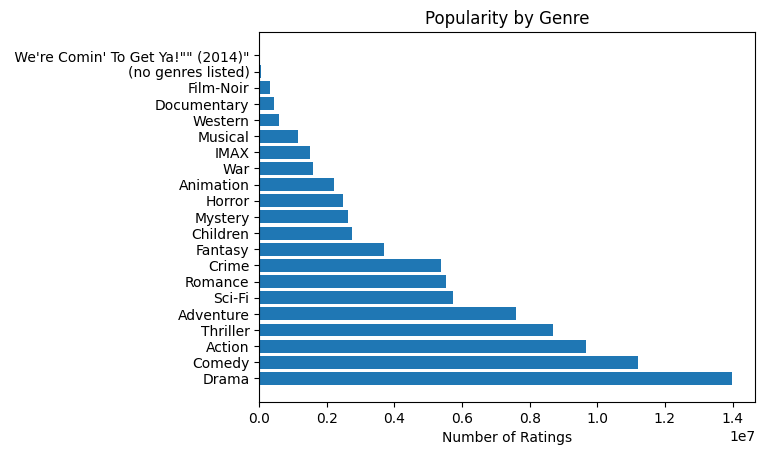

In [0]:
pop_pd = genre_popularity.toPandas()

plt.figure()
plt.barh(pop_pd["genre"], pop_pd["num_ratings"])
plt.xlabel("Number of Ratings")
plt.title("Popularity by Genre")
plt.show()

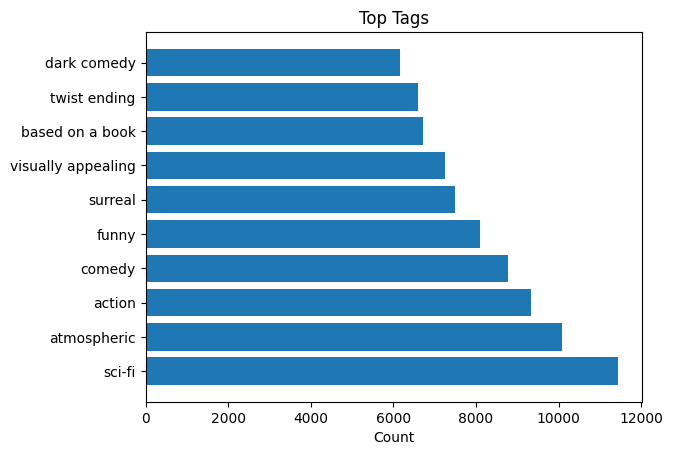

In [0]:
tag_pd = tag_counts.limit(10).toPandas()

plt.figure()
plt.barh(tag_pd["tag"], tag_pd["count"])
plt.xlabel("Count")
plt.title("Top Tags")
plt.show()

Title adn avg rating